In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

In [2]:
# Generate some data
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=400, centers=4,
                       cluster_std=0.60, random_state=0)
X = X[:, ::-1] # flip axes for better plotting

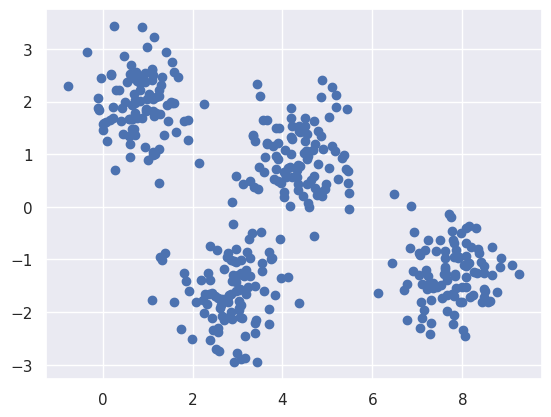

In [3]:
plt.scatter(X[:, 0], X[:, 1]);

In [21]:
from matplotlib.patches import Ellipse
GMM = GaussianMixture(n_components=4, random_state=0).fit(X)

def draw_ellipse(position, covariance, ax=None, **kwargs):
    """Draw an ellipse with a given position and covariance"""
    ax = ax or plt.gca()
    
    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    
    # Draw the Ellipse
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(xy=position,
                             width=nsig * width,
                             height=nsig * height,
                             angle=angle,
                             **kwargs
        ))
        
def plot_gmm(gmm, X, label=True, ax=None):
    ax = ax or plt.gca()
    labels = gmm.predict(X)
    if label:
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2)
    else:
        ax.scatter(X[:, 0], X[:, 1], s=40, zorder=2)
    ax.axis('equal')
    
    w_factor = 0.2 / gmm.weights_.max()
    for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
        draw_ellipse(pos, covar, alpha=w / w_factor) # complete here

In [23]:
kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto")

In [24]:
kmeans.fit(X)
score = kmeans.score(X)
score

-280.00326975400736

In [28]:
gmm1 = GaussianMixture(n_components=4, random_state=0).fit(X)
score = gmm1.score(X)
score

-3.1621889167900603

In [35]:
prob = gmm1.predict_proba(X)
prob.shape

(400, 4)

In [46]:
size = prob.max(axis=1) * 60
label = gmm1.predict(X)

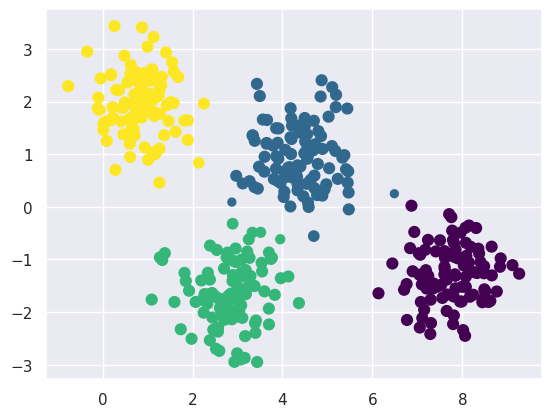

In [48]:
plt.scatter(X[:,0],X[:,1], s=size, c=label, cmap="viridis")

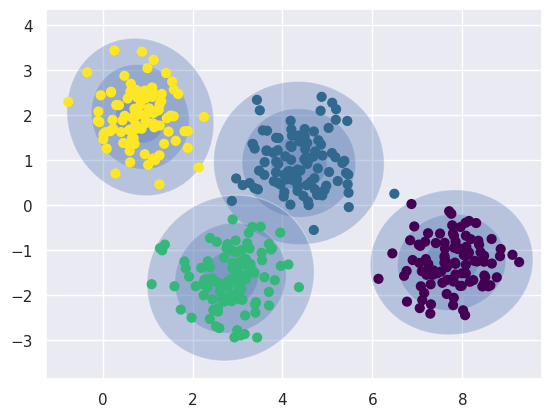

In [51]:
plot_gmm(gmm1, X)